# ***Give Me Some Credit*: Exploratory Data Analysis**

**Give Me Some Credit** to konkurs Kaggle (2011) z dziedziny credit scoringu. Zadanie: oszacować prawdopodobieństwo, że kredytobiorca doświadczy poważnego opóźnienia w spłacie (90+ dni) w ciągu najbliższych 2 lat - klasyczny problem risk modeling, jakiego banki używają przy decyzjach kredytowych (czy przyznać kredyt, jaką ustalić linię kredytową, jakie oprocentowanie).

Zbiór: **~150 000 anonimowych klientów**, 10 cech opisujących historię spłat, zadłużenie, dochód i sytuację demograficzną oraz binarną etykietę (target).

Ten notebook to pierwszy krok projektu - eksploracyjna analiza danych pod kątem jakości (braki, błędne kody, outliery) i relacji cech z etykietą. Wnioski stąd są bezpośrednią przyczyną podjętych decyzji projektowych w `src/ml/data/preprocessing.py`.

### **Objaśnienie kolumn**

| Kolumna | Opis |
|---|---|
| `SeriousDlqin2yrs` | **Target.** Wartość równa 1 oznacza, ze klient miał poważne opóźnienie (tzw. *default*), wynoszące powyzej 90 dni, w spłacie w ciągu 2 lat, a 0 znaczy ze nie miał |
| `RevolvingUtilizationOfUnsecuredLines` | Saldo na kartach kredytowych / liniach odnawialnych podzielone przez sumę limitów kredytowych |
| `age` | Wiek kredytobiorcy w latach |
| `NumberOfTime30-59DaysPastDueNotWorse` | Liczba przypadków opóźnienia płatności wynoszącego 30–59 dni w ciągu ostatnich 2 lat |
| `DebtRatio` | Miesięczne zobowiązania (raty, alimenty, koszty życia) podzielone przez miesięczny dochód brutto |
| `MonthlyIncome` | Miesięczny dochód brutto |
| `NumberOfOpenCreditLinesAndLoans` | Liczba otwartych kredytów i kart kredytowych |
| `NumberOfTimes90DaysLate` | Liczba przypadków opóźnienia płatności wynoszącego powyzej 90 dni |
| `NumberRealEstateLoansOrLines` | Liczba kredytów hipotecznych / linii kredytowych na nieruchomości |
| `NumberOfTime60-89DaysPastDueNotWorse` | Liczba przypadków opóźnienia płatności wynoszącego 60–89 dni w ciągu ostatnich 2 lat |
| `NumberOfDependents` | Liczba osób na utrzymaniu kredytobiorcy (bez niego samego) |

### **Import i konfiguracja**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from ml.data.loader import load_and_split, load_raw_data
from ml.data.preprocessing import build_preprocessing_pipeline

BLUE = "#2a78d6"
ORANGE = "#eb6834"
RED = "#e34948"
GOOD = "#0ca30c"
CRITICAL = "#d03b3b"
PRIMARY_INK = "#0b0b0b"
MUTED_INK = "#898781"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

BLUE_SEQ = LinearSegmentedColormap.from_list("blue_seq", [SURFACE, BLUE])
BLUE_RED_DIVERGING = LinearSegmentedColormap.from_list("blue_red", [BLUE, "#f0efec", RED])

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": PRIMARY_INK,
    "text.color": PRIMARY_INK,
    "xtick.color": MUTED_INK,
    "ytick.color": MUTED_INK,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

pd.set_option("display.max_columns", None)


### **Wczytanie danych**

In [2]:
df = load_raw_data()
print(f"Liczba obserwacji: {df.shape[0]}")
print(f"Liczba cech: {df.shape[1]}")
df.info()

Liczba obserwacji: 150000
Liczba cech: 11
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                   

## **Statystyki opisowe**

Podstawowe statystyki dla każdej kolumny: liczba braków, średnia/odchylenie, kwartyle, skośność (`skew`) i liczba unikalnych wartości. Skośność i braki są podświetlone — im ciemniejszy odcień, tym większa wartość. To wstępna mapa problemów, które dalej analizujemy szczegółowo (braki, sentinel values, outliery).

In [3]:
stats = df.describe().T
stats["missing"] = df.isna().sum()
stats["missing_pct"] = (df.isna().mean() * 100).round(2)
stats["skew"] = df.skew(numeric_only=True).round(2)
stats["nunique"] = df.nunique()
stats = stats[["count", "missing", "missing_pct", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "nunique"]]

stats.style.background_gradient(subset=["missing_pct", "skew"], cmap=BLUE_SEQ).format(precision=2)


,count,missing,missing_pct,mean,std,min,25%,50%,75%,max,skew,nunique
SeriousDlqin2yrs,150000.00,0,0.00,0.07,0.25,0.00,0.00,0.00,0.00,1.00,3.47,2
RevolvingUtilizationOfUnsecuredLines,150000.00,0,0.00,6.05,249.76,0.00,0.03,0.15,0.56,50708.00,97.63,125728
age,150000.00,0,0.00,52.30,14.77,0.00,41.00,52.00,63.00,109.00,0.19,86
NumberOfTime30-59DaysPastDueNotWorse,150000.00,0,0.00,0.42,4.19,0.00,0.00,0.00,0.00,98.00,22.60,16
DebtRatio,150000.00,0,0.00,353.01,2037.82,0.00,0.18,0.37,0.87,329664.00,95.16,114194
MonthlyIncome,120269.00,29731,19.82,6670.22,14384.67,0.00,3400.00,5400.00,8249.00,3008750.00,114.04,13594
NumberOfOpenCreditLinesAndLoans,150000.00,0,0.00,8.45,5.15,0.00,5.00,8.00,11.00,58.00,1.22,58
NumberOfTimes90DaysLate,150000.00,0,0.00,0.27,4.17,0.00,0.00,0.00,0.00,98.00,23.09,19
NumberRealEstateLoansOrLines,150000.00,0,0.00,1.02,1.13,0.00,0.00,1.00,2.00,54.00,3.48,28
NumberOfTime60-89DaysPastDueNotWorse,150000.00,0,0.00,0.24,4.16,0.00,0.00,0.00,0.00,98.00,23.33,13


## **Histogramy cech (analiza ilościowa)**

Szybki przegląd kształtu i skali każdej surowej cechy. Oś X przycięta do przedziału od 1. do 99. percentyla **wyłącznie do wizualizacji** (dane źródłowe nie są modyfikowane) — bez tego ekstremalne outliery (widoczne dalej w dedykowanej sekcji) spłaszczyłyby niektóre histogramy do jednego słupka.

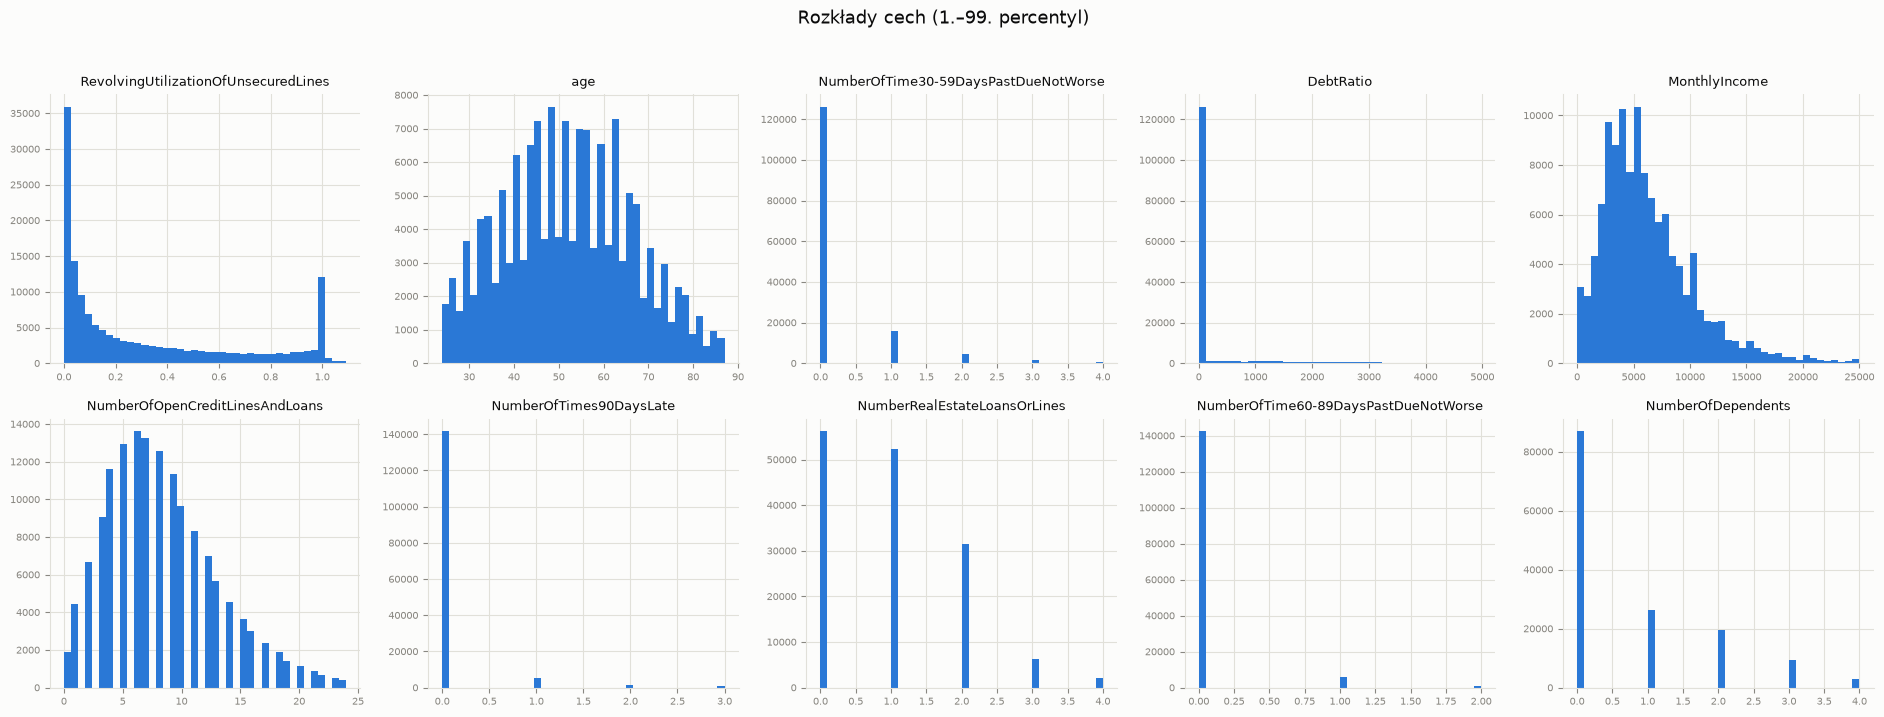

In [4]:
feature_cols = [c for c in df.columns if c != "SeriousDlqin2yrs"]

fig, axes = plt.subplots(2, 5, figsize=(19, 7))
for ax, col in zip(axes.flat, feature_cols):
    data = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    display_data = data[(data >= lo) & (data <= hi)] if hi > lo else data
    ax.hist(display_data, bins=40, color=BLUE)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle("Rozkłady cech (1.–99. percentyl)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## **Rozkład zmiennej celu (class imbalance)**

`SeriousDlqin2yrs` jest silnie niezbalansowany — to determinuje wybór metryk (precision/recall/F1/PR-AUC zamiast accuracy) w całym dalszym projekcie: model, który zawsze przewiduje klasę wiekszościową (brak *default*), miałby ~93% accuracy i byłby bezużyteczny.

/var/folders/8m/nx_b_wh17dg77b9kb95gxng80000gp/T/ipykernel_78010/3634928245.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


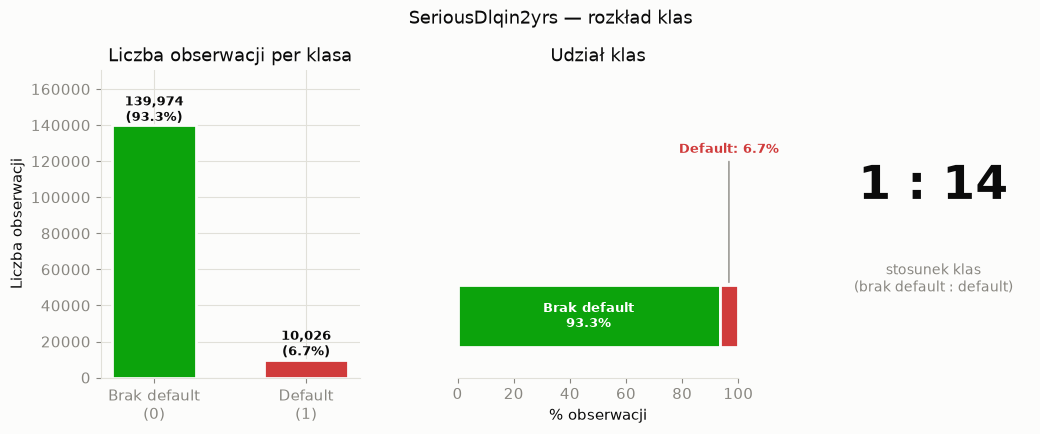

In [5]:
counts = df["SeriousDlqin2yrs"].value_counts().sort_index()
pct = counts / counts.sum() * 100
ratio = counts[0] / counts[1]

fig = plt.figure(figsize=(12, 4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.3, 0.9], wspace=0.4)
ax_bar, ax_stack, ax_stat = (fig.add_subplot(gs[i]) for i in range(3))

bars = ax_bar.bar(
    ["Brak default\n(0)", "Default\n(1)"],
    counts.values,
    color=[GOOD, CRITICAL],
    width=0.55,
    edgecolor=SURFACE,
    linewidth=2,
)
for bar, c, p in zip(bars, counts.values, pct.values):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{c:,}\n({p:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=9,
    )
ax_bar.set_ylabel("Liczba obserwacji")
ax_bar.set_title("Liczba obserwacji per klasa")
ax_bar.set_ylim(0, counts.max() * 1.22)

left = 0
segments = [(GOOD, "Brak default", pct[0]), (CRITICAL, "Default", pct[1])]
for color, label, width in segments:
    ax_stack.barh([0], [width], left=left, color=color, height=0.5, edgecolor=SURFACE, linewidth=2)
    if width >= 15:
        ax_stack.text(left + width / 2, 0, f"{label}\n{width:.1f}%", ha="center", va="center", color="white", fontweight="bold", fontsize=9)
    else:
        ax_stack.annotate(
            f"{label}: {width:.1f}%",
            xy=(left + width / 2, 0.25),
            xytext=(left + width / 2, 1.3),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=CRITICAL,
            arrowprops=dict(arrowstyle="-", color=MUTED_INK, lw=1),
        )
    left += width
ax_stack.set_xlim(0, 100)
ax_stack.set_ylim(-0.5, 2.0)
ax_stack.set_yticks([])
ax_stack.set_xlabel("% obserwacji")
ax_stack.set_title("Udział klas")
for spine in ["top", "right", "left"]:
    ax_stack.spines[spine].set_visible(False)
ax_stack.grid(False)

ax_stat.axis("off")
ax_stat.text(0.5, 0.62, f"1 : {ratio:.0f}", ha="center", va="center", fontsize=34, fontweight="bold", color=PRIMARY_INK)
ax_stat.text(0.5, 0.32, "stosunek klas\n(brak default : default)", ha="center", va="center", fontsize=10, color=MUTED_INK)

plt.suptitle("SeriousDlqin2yrs — rozkład klas", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


## **Braki danych (missing values)**

Kolumny `MonthlyIncome` i `NumberOfDependents` mają braki. Skala braków w `MonthlyIncome` (~20%) jest na tyle duża, że decydujemy się nie tylko imputować, ale też zachować informację o tym, które wiersze były brakujące.

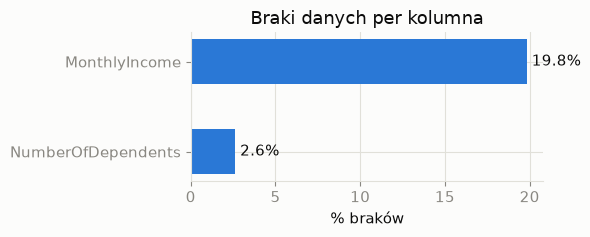

In [6]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.barh(missing_pct.index, missing_pct.values, color=BLUE, height=0.5)
for bar, pct in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}%", va="center", color=PRIMARY_INK)
ax.set_xlabel("% braków")
ax.set_title("Braki danych per kolumna")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## **Sentinel values w kolumnach opóźnień**

Kolumny `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfTimes90DaysLate` zawierają wartości 96/98, które nie są realną liczbą opóźnień, tylko kodem błędu ze źródła danych (tzw. sentinel value). Sprawdzamy, czy te wiersze niosą sygnał predykcyjny.

Wiersze z sentinelem per kolumna: {'NumberOfTime30-59DaysPastDueNotWorse': 269, 'NumberOfTime60-89DaysPastDueNotWorse': 269, 'NumberOfTimes90DaysLate': 269}
Te same wiersze we wszystkich 3 kolumnach: True


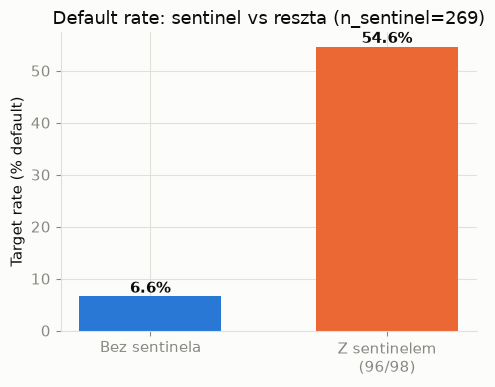

In [7]:
delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]
sentinel_mask = df[delinquency_cols].isin([96, 98])

print("Wiersze z sentinelem per kolumna:", sentinel_mask.sum().to_dict())
print("Te same wiersze we wszystkich 3 kolumnach:", (sentinel_mask.nunique(axis=1) == 1).all())

has_sentinel = sentinel_mask.any(axis=1)
target_rate = df.groupby(has_sentinel)["SeriousDlqin2yrs"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["Bez sentinela", "Z sentinelem\n(96/98)"],
    target_rate.values * 100,
    color=[BLUE, ORANGE],
    width=0.6,
)
for bar, val in zip(bars, target_rate.values * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Target rate (% default)")
ax.set_title(f"Default rate: sentinel vs reszta (n_sentinel={has_sentinel.sum()})")
plt.tight_layout()
plt.show()


## **Outliery — DebtRatio i RevolvingUtilizationOfUnsecuredLines**

Obie kolumny mają ekstremalnie prawoskośne rozkłady (max rzędu dziesiątek/setek tysięcy przy medianie mniejszej niz 1). Oś X została zaprezentowana w skali logarytmicznej, żeby w ogóle było widać kształt rozkładu.

           DebtRatio  RevolvingUtilizationOfUnsecuredLines
count  150000.000000                         150000.000000
mean      353.005076                              6.048438
std      2037.818523                            249.755371
min         0.000000                              0.000000
25%         0.175074                              0.029867
50%         0.366508                              0.154181
75%         0.868254                              0.559046
max    329664.000000                          50708.000000


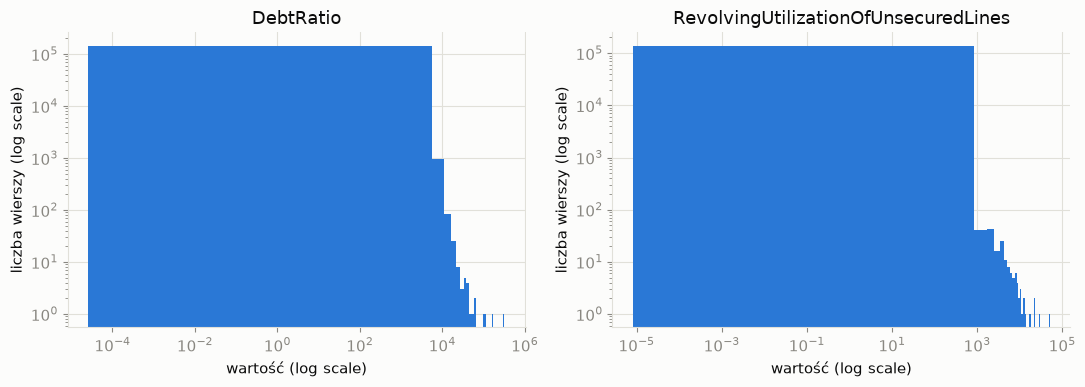

In [8]:
outlier_cols = ["DebtRatio", "RevolvingUtilizationOfUnsecuredLines"]
print(df[outlier_cols].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, outlier_cols):
    values = df[col][df[col] > 0]
    ax.hist(values, bins=60, color=BLUE, log=True)
    ax.set_xscale("log")
    ax.set_title(col)
    ax.set_xlabel("wartość (log scale)")
    ax.set_ylabel("liczba wierszy (log scale)")
plt.tight_layout()
plt.show()


## **Wiek - sanity check**

Kolumna `age` powinna mieć sensowny dolny próg, tj. wnioskodawca kredytu powinien być dorosły. Nalezy więc sprawdzić, czy są rekordy, gdzie wiek ma wartość poniżej progu. Większy problem pojawia się przy wartościach blizej górnego końca rozkładu - mało prawdopodobnym (choć technicznie mozliwym) jest by wnioskodawca miał 109 lat, ale dla prostoty mozna przyjąć ze wartosci te są zgodne z rzeczywistością.

age min/max: 0 109
wiersze z age < 18:
       age  SeriousDlqin2yrs
65696    0                 0


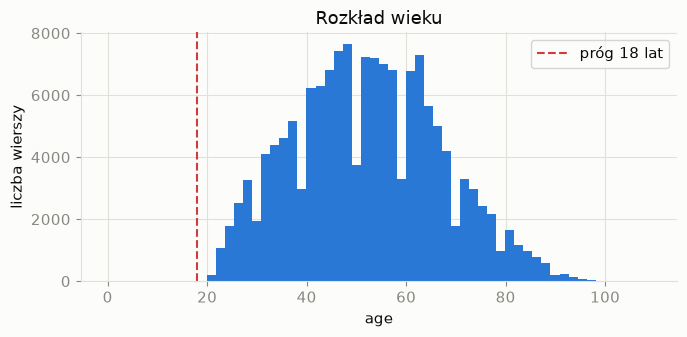

In [9]:
print("age min/max:", df["age"].min(), df["age"].max())
print("wiersze z age < 18:")
print(df[df["age"] < 18][["age", "SeriousDlqin2yrs"]])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(df["age"], bins=60, color=BLUE)
ax.axvline(18, color=CRITICAL, linestyle="--", linewidth=1.5, label="próg 18 lat")
ax.set_xlabel("age")
ax.set_ylabel("liczba wierszy")
ax.set_title("Rozkład wieku")
ax.legend()
plt.tight_layout()
plt.show()


## **Datacleaning pipeline - before vs after**

Uruchamiamy metodę `fit` z `build_preprocessing_pipeline()` z `src/ml/data/preprocessing.py` wyłącznie na train, `transform` na train i test. Pozwala to uniknąć wycieku statystyk testowych do treningu (tzw. *data leakage*). Zaprojektowany pipeline jest odpowiedzią na wszystkie zdiagnozowane powyzej problemy, a ponadto aby uniknac zbyt wysokich wartości, które mogłyby utrudnić prawidłowe przewidywanie, obcinamy wartości najwyzsze wartosci do 99. centyla.

Nowe kolumny: ['MonthlyIncome_was_missing', 'has_delinquency_sentinel']
NaN po czyszczeniu — train: False | test: False


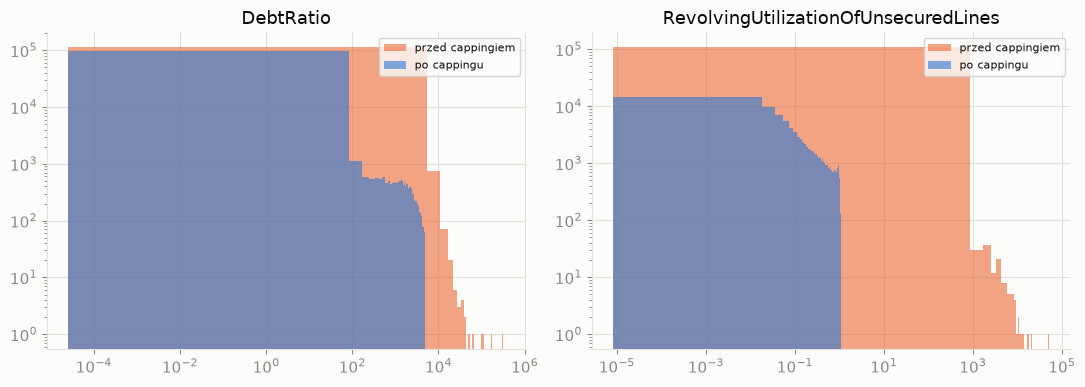

In [10]:
train_df, test_df = load_and_split()

pipeline = build_preprocessing_pipeline()
train_clean = pipeline.fit_transform(train_df)
test_clean = pipeline.transform(test_df)

print("Nowe kolumny:", sorted(set(train_clean.columns) - set(train_df.columns)))
print("NaN po czyszczeniu — train:", train_clean.isna().any().any(), "| test:", test_clean.isna().any().any())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, outlier_cols):
    before = train_df[col][train_df[col] > 0]
    after = train_clean[col][train_clean[col] > 0]
    ax.hist(before, bins=60, color=ORANGE, alpha=0.6, log=True, label="przed cappingiem")
    ax.hist(after, bins=60, color=BLUE, alpha=0.6, log=True, label="po cappingu")
    ax.set_xscale("log")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## **Korelacja cech z targetem (na wyczyszczonych danych)**

Wizualizacja pokazuje korelację cech z targetem - kolor niebieski oznacza pozytywną korelację, a kolor czerwony ujemną. Na podstawie wykresu mozna wysnuć kilka oczywistych wniosków - najbardziej istotne dla przewidywania czy wnioskodawca spłaci kredyt w terminie jest historia jego dotychczasowych spłat. Z drugiej strony, najmniej przydatne dla przewidywania jest wiek wnioskodawcy.

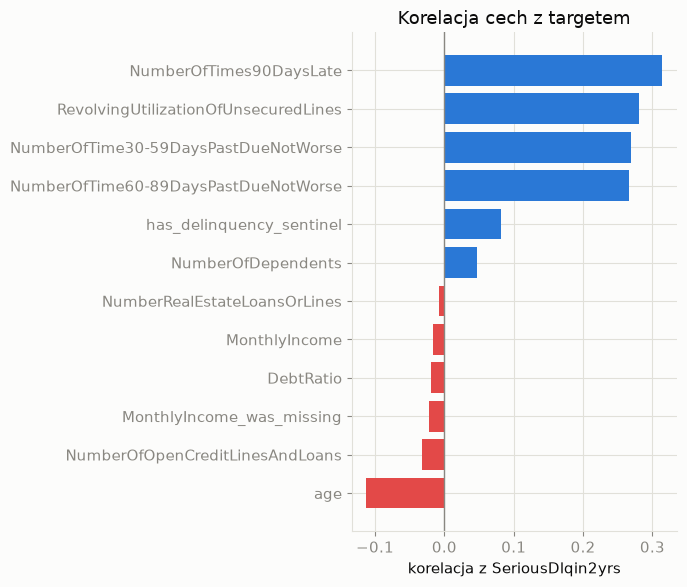

In [12]:
target_col = "SeriousDlqin2yrs"
corr = (
    train_clean.corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values()
)

colors = [BLUE if v > 0 else RED for v in corr.values]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color=MUTED_INK, linewidth=1)
ax.set_xlabel("korelacja z SeriousDlqin2yrs")
ax.set_title("Korelacja cech z targetem")
plt.tight_layout()
plt.show()


## **Macierz korelacji cech**

Cechy są ze sobą (nie tylko z targetem) skorelowane, co jest istotne pod kątem współliniowości (multicollinearity), która szkodzi interpretowalności i stabilności współczynników w regresji liniowej i wpływa na SVM. Górny trójkąt macierzy został ukryty, żeby nie duplikować informacji, choć w praktyce jest on symetryczny w stosunku do dolnego trójkąta.

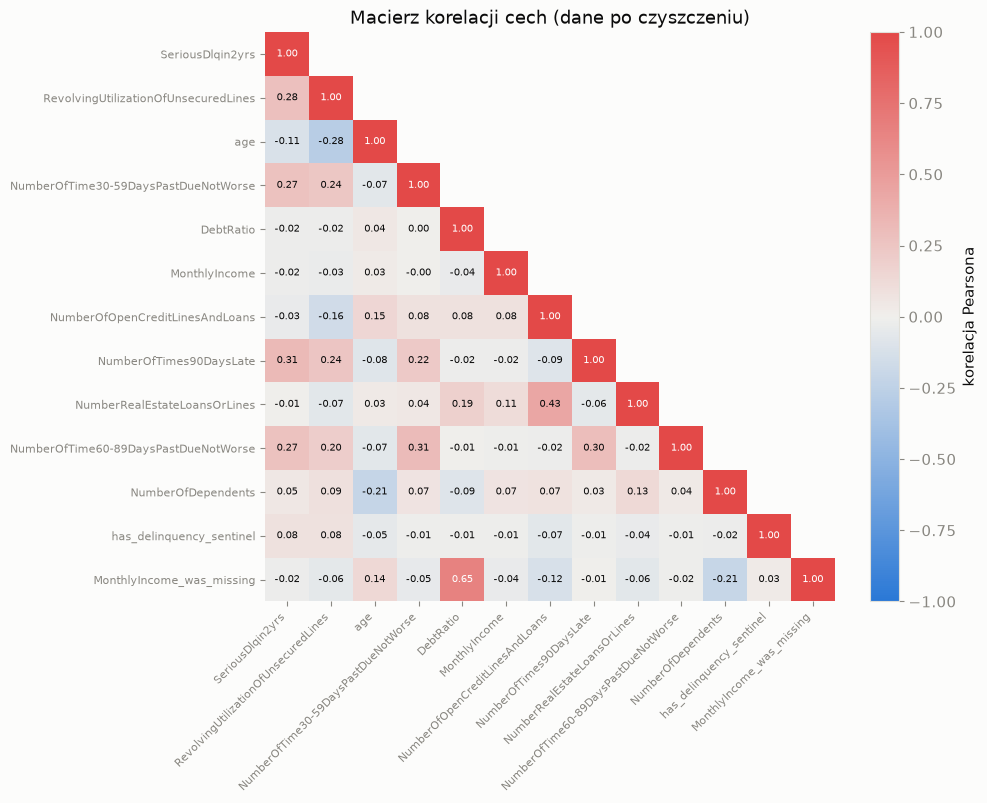

In [ ]:
corr_matrix = train_clean.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_display = corr_matrix.mask(mask)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr_display, cmap=BLUE_RED_DIVERGING, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_display.columns)))
ax.set_xticklabels(corr_display.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_display.index)))
ax.set_yticklabels(corr_display.index, fontsize=8)

for i in range(len(corr_display.index)):
    for j in range(len(corr_display.columns)):
        val = corr_display.iloc[i, j]
        if not np.isnan(val):
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.5 else PRIMARY_INK,
            )

ax.grid(False)
ax.spines[:].set_visible(False)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("korelacja Pearsona")
ax.set_title("Macierz korelacji cech (dane po czyszczeniu)")
plt.tight_layout()
plt.show()


**Nieoczywisty wniosek z macierzy**: cecha `DebtRatio` koreluje z cechą `MonthlyIncome_was_missing` na poziomie **0.65** — bardzo silnie jak na cechę pochodną, sygnalizującą brak miesięcznych przychodów w danych. Sprawdzenie na surowych danych pokazuje dlaczego: gdy `MonthlyIncome` jest brakujący, `DebtRatio` jest większy od 1 w **93.9%** wierszy, a gdy dochód jest znany — tylko w 6% . Innymi słowy: dla wierszy z brakującym dochodem, `DebtRatio` prawdopodobnie **nie jest realnym stosunkiem dług/dochód**, tylko artefaktem obliczeniowym ze źródła danych — kolejny argument za tym, że flaga `MonthlyIncome_was_missing` jest wartościową cechą, nie tylko techniczną łatką na braki.

## **Podsumowanie ustaleń**

- **Target silnie niezbalansowany** (~6.7% default, stosunek 1:14) → accuracy jest bezużyteczna jako metryka; cały projekt ocenia modele przez precision/recall/F1/PR-AUC.
- **`MonthlyIncome`** brakuje w ~20% wierszy → mediana + flaga `MonthlyIncome_was_missing`, bo brak dochodu może sam w sobie nieść sygnał ryzyka (MNAR).
- **`NumberOfDependents`** brakuje w ~2.6% wierszy → sama mediana, zbyt mało brakujących by flaga miała sens.
- **Sentinel 96/98** w kolumnach opóźnień to te same 269 wierszy we wszystkich trzech kolumnach, a ich default rate to ~55% vs ~6.7% ogółem — **to nie szum, tylko jeden z najsilniejszych sygnałów w zbiorze**. Imputujemy medianą + zachowujemy jako `has_delinquency_sentinel`.
- **`DebtRatio`** i **`RevolvingUtilizationOfUnsecuredLines`** mają ekstremalne outliery (rzędu dziesiątek tysięcy) → winsoryzacja na 99. percentylu, próg liczony wyłącznie z train.
- **`DebtRatio` jest prawdopodobnie niewiarygodny dla wierszy z brakującym `MonthlyIncome`** (korelacja 0.65 z flagą braku, `DebtRatio > 1` w 93.9% takich wierszy vs 6% gdy dochód jest znany) — kolejny dowód na wartość flagi `MonthlyIncome_was_missing` jako osobnej cechy.
- **`age`** ma jeden błędny rekord (0 lat) → przycięty do dolnego progu 18 lat (reguła domenowa, nie statystyczna).
- Wszystkie statystyki imputacji/cappingu liczone **wyłącznie na train**, potem aplikowane do test — bez wycieku danych (`src/ml/data/preprocessing.py`).